In [1]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import IidPartitioner, ShardPartitioner, PathologicalPartitioner, DirichletPartitioner
from flwr_datasets.visualization import plot_label_distributions

/home/ntdung/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
partitioner_list = []
title_list = ["IidPartitioner", "ShardPartitioner", "PathologicalPartitioner", "DirichletPartitioner"]

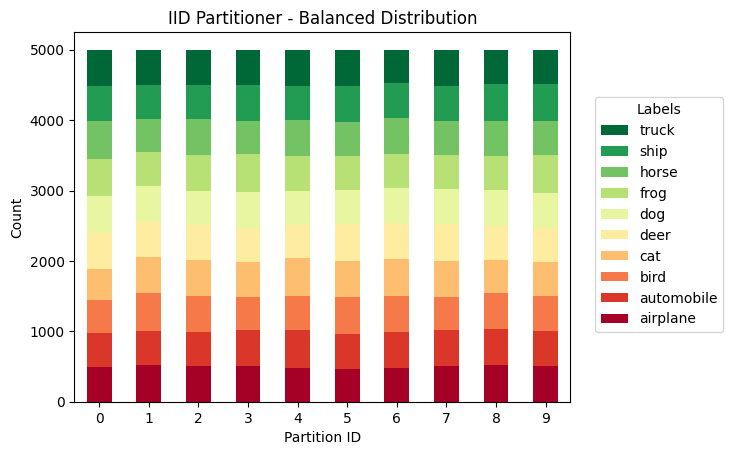

In [3]:
fds = FederatedDataset(
    dataset="cifar10",
    partitioners={
        "train": IidPartitioner(num_partitions=10),
    },
)
partitioner_list.append(fds.partitioners["train"])

fig, ax, df = plot_label_distributions(
    partitioner_list[0],
    label_name="label",
    plot_type="bar",
    size_unit="absolute",
    legend=True,
    verbose_labels=True,
    title="IID Partitioner - Balanced Distribution",
)

In [4]:
df['Total Samples'] = df.sum(axis=1)
print("=== IID Partitioner ===")
df

=== IID Partitioner ===


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck,Total Samples
Partition ID,,,,,,,,,,,
0,490,487,463,447,513,517,526,539,502,516,5000
1,521,482,544,511,501,504,484,467,487,499,5000
2,514,474,517,507,500,488,499,522,480,499,5000
3,506,507,476,489,484,513,544,471,510,500,5000
4,486,535,476,545,468,485,500,510,480,515,5000
5,466,498,524,507,530,488,476,489,508,514,5000
6,486,501,518,519,515,502,483,510,499,467,5000
7,503,513,474,513,520,497,479,490,492,519,5000
8,525,508,506,477,485,505,481,506,525,482,5000


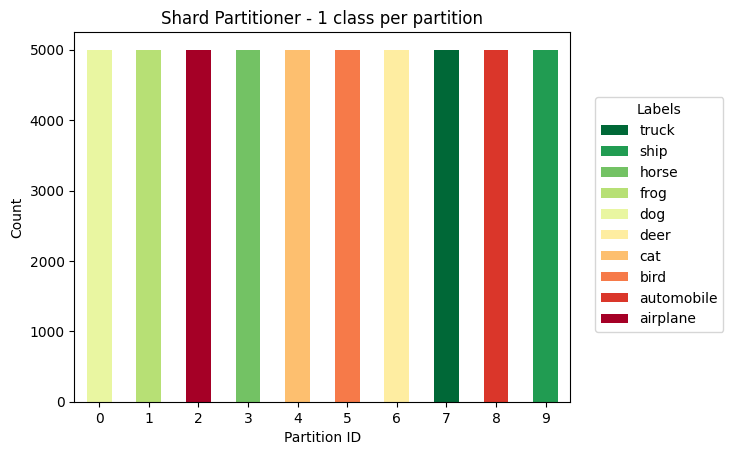

In [5]:
fds = FederatedDataset(
    dataset="cifar10",
    partitioners={
        "train": ShardPartitioner(
            num_partitions=10, 
            partition_by="label", 
            num_shards_per_partition=1
        )
    },
)
partitioner_list.append(fds.partitioners["train"])

fig, ax, df = plot_label_distributions(
    partitioner_list[1],
    label_name="label",
    plot_type="bar",
    title="Shard Partitioner - 1 class per partition",
    legend=True,
    verbose_labels=True,
    size_unit="absolute",
)

In [6]:
df['Total Samples'] = df.sum(axis=1)
print("=== Shard Partitioner ===")
df

=== Shard Partitioner ===


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck,Total Samples
Partition ID,,,,,,,,,,,
0,0,0,0,0,0,5000,0,0,0,0,5000
1,0,0,0,0,0,0,5000,0,0,0,5000
2,5000,0,0,0,0,0,0,0,0,0,5000
3,0,0,0,0,0,0,0,5000,0,0,5000
4,0,0,0,5000,0,0,0,0,0,0,5000
5,0,0,5000,0,0,0,0,0,0,0,5000
6,0,0,0,0,5000,0,0,0,0,0,5000
7,0,0,0,0,0,0,0,0,0,5000,5000
8,0,5000,0,0,0,0,0,0,0,0,5000


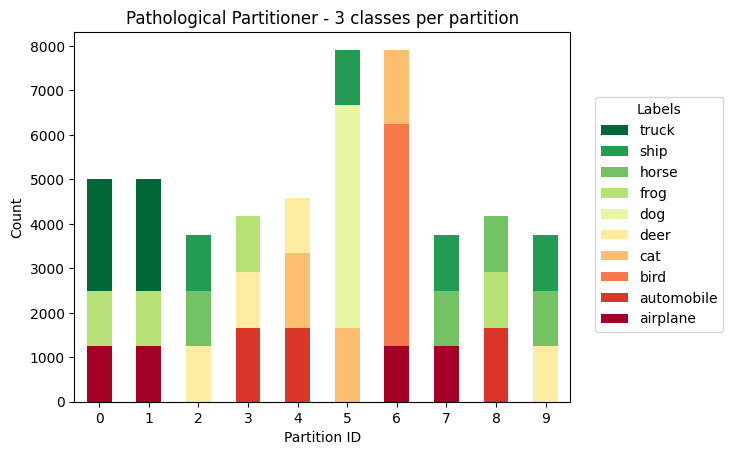

In [15]:
fds = FederatedDataset(
    dataset="cifar10",
    partitioners={
        "train": PathologicalPartitioner(
            num_partitions=10, 
            partition_by="label", 
            num_classes_per_partition=3,
            class_assignment_mode="random",
        )
    },
)
partitioner_list.append(fds.partitioners["train"])

fig, ax, df = plot_label_distributions(
    partitioner_list[2],
    label_name="label",
    plot_type="bar",
    size_unit="absolute",
    legend=True,
    verbose_labels=True,
    title="Pathological Partitioner - 3 classes per partition",
)

In [16]:
df['Total Samples'] = df.sum(axis=1)
print("=== Pathological Partitioner ===")
df

=== Pathological Partitioner ===


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck,Total Samples
Partition ID,,,,,,,,,,,
0,1250,0,0,0,0,0,1250,0,0,2500,5000
1,1250,0,0,0,0,0,1250,0,0,2500,5000
2,0,0,0,0,1250,0,0,1250,1250,0,3750
3,0,1667,0,0,1250,0,1250,0,0,0,4167
4,0,1667,0,1667,1250,0,0,0,0,0,4584
5,0,0,0,1667,0,5000,0,0,1250,0,7917
6,1250,0,5000,1666,0,0,0,0,0,0,7916
7,1250,0,0,0,0,0,0,1250,1250,0,3750
8,0,1666,0,0,0,0,1250,1250,0,0,4166


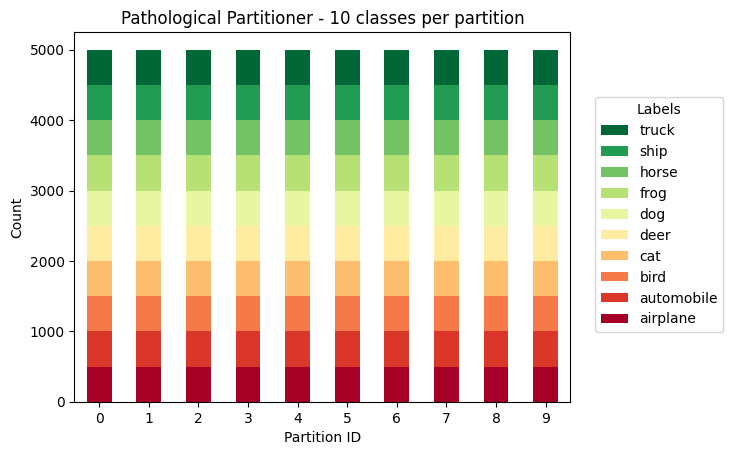

In [17]:
fds = FederatedDataset(
    dataset="cifar10",
    partitioners={
        "train": PathologicalPartitioner(
            num_partitions=10, 
            partition_by="label", 
            num_classes_per_partition=10,
            class_assignment_mode="random",
        )
    },
)
partitioner = fds.partitioners["train"]

fig, ax, df = plot_label_distributions(
    partitioner,
    label_name="label",
    plot_type="bar",
    size_unit="absolute",
    legend=True,
    verbose_labels=True,
    title="Pathological Partitioner - 10 classes per partition",
)

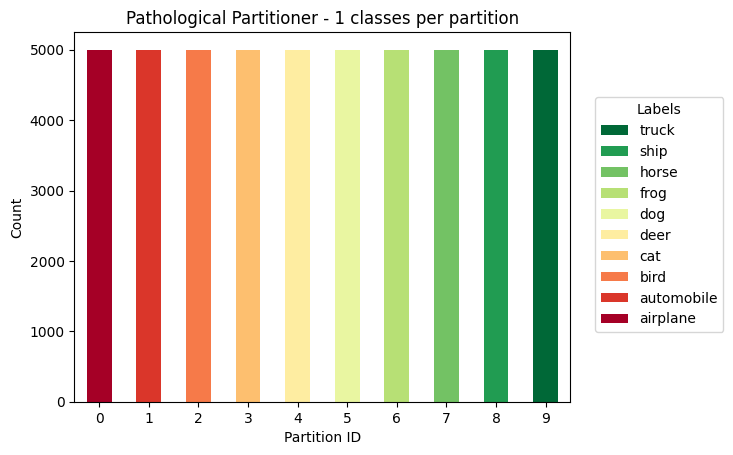

In [32]:
fds = FederatedDataset(
    dataset="cifar10",
    partitioners={
        "train": PathologicalPartitioner(
            num_partitions=10, 
            partition_by="label", 
            num_classes_per_partition=1,
            class_assignment_mode="first-deterministic",
        )
    },
)
partitioner = fds.partitioners["train"]

fig, ax, df = plot_label_distributions(
    partitioner,
    label_name="label",
    plot_type="bar",
    size_unit="absolute",
    legend=True,
    verbose_labels=True,
    title="Pathological Partitioner - 1 classes per partition",
)

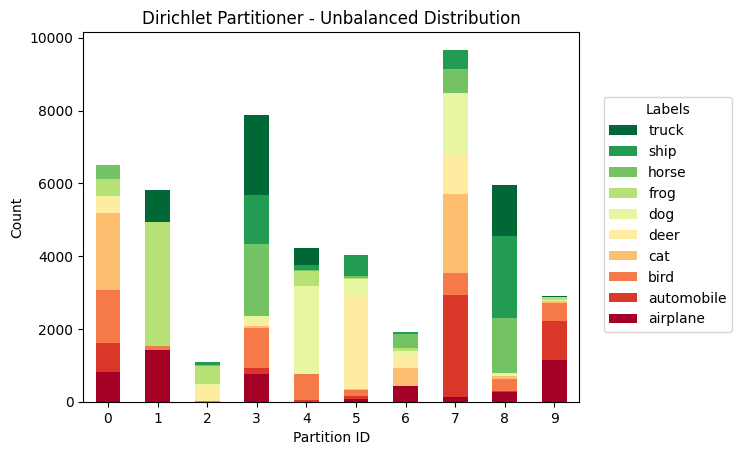

In [10]:
fds = FederatedDataset(
    dataset="cifar10",
    partitioners={
        "train": DirichletPartitioner(
            num_partitions=10,
            partition_by="label",
            alpha=0.3,
            seed=42,
            min_partition_size=0,
        ),
    },
)
partitioner_list.append(fds.partitioners["train"])

fig, ax, df = plot_label_distributions(
    partitioner_list[3],
    label_name="label",
    plot_type="bar",
    size_unit="absolute",
    legend=True,
    verbose_labels=True,
    title="Dirichlet Partitioner - Unbalanced Distribution",
)


In [11]:
df['Total Samples'] = df.sum(axis=1)
print("=== Dirichlet Partitioner ===")
df

=== Dirichlet Partitioner ===


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck,Total Samples
Partition ID,,,,,,,,,,,
0,817,794,1462,2123,432,25,456,384,14,9,6516
1,1416,6,97,5,3,0,3409,0,3,868,5807
2,0,4,11,2,454,3,511,15,84,21,1105
3,762,159,1100,51,120,166,2,1982,1351,2175,7868
4,2,43,714,2,19,2400,425,1,151,477,4234
5,67,79,170,25,2552,477,27,44,590,0,4031
6,422,2,4,486,380,92,90,380,50,6,1912
7,122,2811,597,2174,1038,1727,1,682,515,4,9671
8,256,29,342,75,1,84,8,1511,2240,1417,5963


c:\Users\Tien Dung\miniconda3\envs\py311\Lib\site-packages\flwr_datasets\visualization\comparison_label_distribution.py:222: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Text(0.5, 0.01, 'Class percentage')

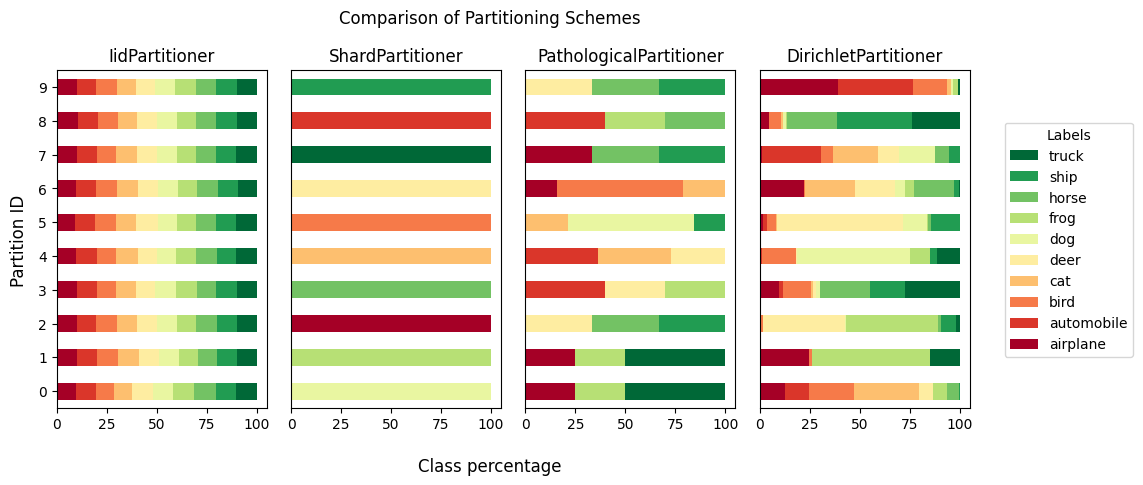

In [13]:
from flwr_datasets.visualization import plot_comparison_label_distribution

fig, axes, df_list = plot_comparison_label_distribution(
    partitioner_list=partitioner_list,
    label_name="label",
    subtitle="Comparison of Partitioning Schemes",
    titles=title_list,
    legend=True,
    verbose_labels=True,
)

fig.supxlabel("Class percentage") 